# Exp01: Hard Negative Mining

## 실험 목적
- HNM 데이터셋으로 재학습하여 분류 정확도 향상 확인
- Baseline vs HNM 데이터셋 성능 비교

## 관련 논문
- **Training Region-based Object Detectors with Online Hard Example Mining**
- 저자: Shrivastava, Gupta, Girshick (CVPR 2016)
- 핵심: "Detection datasets contain an overwhelming number of easy examples and a small number of hard examples."

In [24]:
!pip install ultralytics

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import yaml
from pathlib import Path
from collections import Counter

# GPU 확인
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# 프로젝트 루트 경로 (Google Drive)
PROJECT_ROOT = Path("/content/drive/MyDrive")
print(f"Project Root: {PROJECT_ROOT}")

Device: cuda
GPU: Tesla T4
Project Root: /content/drive/MyDrive


## 1. 데이터 준비

### HNM Dataset 구조
- images/train: 843장 (학습용)
- images/val: 2000장 (검증용)
- labels/train, labels/val: 라벨 파일
- data.yaml에서 train/val 경로 지정

In [27]:
# HNM 데이터셋 경로
HNM_DIR = PROJECT_ROOT / "AI" / "data" / "hnm_dataset"
HNM_IMAGES = HNM_DIR / "images"

# 클래스 정의
CLASS_NAMES = {0: "Can", 1: "Pet bottle", 2: "Styrofoam"}

# HNM 데이터셋 분석
print("=== HNM Dataset Structure ===")
print(f"Path: {HNM_DIR}")
print()

for split in ["train", "val"]:
    split_dir = HNM_IMAGES / split
    if split_dir.exists():
        img_files = list(split_dir.glob("*.jpg")) + list(split_dir.glob("*.png"))
        print(f"{split}: {len(img_files)} images")
    else:
        print(f"{split}: Directory not found")

# 클래스별 분포 확인 (train 라벨)
HNM_LABELS = HNM_DIR / "labels"
train_label_dir = HNM_LABELS / "train"

if train_label_dir.exists():
    label_files = list(train_label_dir.glob("*.txt"))
    class_counts = {0: 0, 1: 0, 2: 0}
    for label_file in label_files:
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) > 0:
                    cls_id = int(parts[0])
                    if cls_id in class_counts:
                        class_counts[cls_id] += 1

    print("\n=== Class Distribution (Train) ===")
    for cls_id, cls_name in CLASS_NAMES.items():
        print(f"{cls_name}: {class_counts[cls_id]} instances")

=== HNM Dataset Structure ===
Path: /content/drive/MyDrive/AI/data/hnm_dataset

train: 843 images
val: 2000 images

=== Class Distribution (Train) ===
Can: 469 instances
Pet bottle: 908 instances
Styrofoam: 909 instances


## 2. 검증 데이터

- HNM 데이터셋의 val set 사용 (data.yaml에서 지정)

In [28]:
# HNM 데이터셋 val set 분석
HNM_VAL = HNM_IMAGES / "val"

print("=== HNM Dataset Val Set ===")
print(f"Path: {HNM_VAL}")

if HNM_VAL.exists():
    val_images = list(HNM_VAL.glob("*.jpg")) + list(HNM_VAL.glob("*.png"))
    print(f"Total val images: {len(val_images)}")
else:
    print("Val directory not found")

=== HNM Dataset Val Set ===
Path: /content/drive/MyDrive/AI/data/hnm_dataset/images/val
Total val images: 2000

Data config: {'names': {0: 'Can', 1: 'Pet bottle', 2: 'Styrofoam'}, 'nc': 3, 'path': '.', 'train': 'images/train', 'val': 'images/val'}


In [31]:
# data.yaml 확인
# Update data.yaml to use absolute paths for 'path', 'train', and 'val'

data_yaml_path = HNM_DIR / "data.yaml"

if data_yaml_path.exists():
    with open(data_yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)

    # Set 'path' to the absolute base directory of the dataset
    data_config['path'] = str(HNM_DIR)
    # Set 'train' and 'val' to their absolute image directories
    data_config['train'] = str(HNM_DIR / "images" / "train")
    data_config['val'] = str(HNM_DIR / "images" / "val")

    with open(data_yaml_path, 'w') as f:
        yaml.dump(data_config, f)

    print(f"Updated data.yaml: {data_config}")
else:
    print(f"Error: data.yaml not found at {data_yaml_path}")

Updated data.yaml: {'names': {0: 'Can', 1: 'Pet bottle', 2: 'Styrofoam'}, 'nc': 3, 'path': '/content/drive/MyDrive/AI/data/hnm_dataset', 'train': '/content/drive/MyDrive/AI/data/hnm_dataset/images/train', 'val': '/content/drive/MyDrive/AI/data/hnm_dataset/images/val'}


## 3. 모델 로드

- best.pt 사전학습 가중치 활용

In [29]:
from ultralytics import YOLO

# best.pt 경로
BEST_PT = PROJECT_ROOT / "runs" / "detect" / "runs" / "train_full" / "yolo11n" / "weights" / "best.pt"
print(f"Loading model: {BEST_PT}")
print(f"File exists: {BEST_PT.exists()}")

# 모델 로드
model = YOLO(str(BEST_PT))
print(f"Model loaded: {model.model_name}")

Loading model: /content/drive/MyDrive/runs/detect/runs/train_full/yolo11n/weights/best.pt
File exists: True
Model loaded: /content/drive/MyDrive/runs/detect/runs/train_full/yolo11n/weights/best.pt


## 4. 학습 실행

### 하이퍼파라미터
| 항목 | 값 |
|---|---|
| Epochs | 100 (early stopping patience=20) |
| Batch | 64 |
| Image Size | 640 |
| Optimizer | AdamW |
| LR Scheduler | Cosine (cos_lr=True) |
| Warmup Epochs | 3 |

In [30]:
# 학습 하이퍼파라미터
EPOCHS = 100
BATCH = 64
IMG_SIZE = 640
PATIENCE = 20

# 데이터 경로 (HNM data.yaml 사용 - 상대 경로)
HNM_DATA_DIR = str(PROJECT_ROOT / "AI" / "data" / "hnm_dataset")

print("=== Training Configuration ===")
print(f"Data Dir: {HNM_DATA_DIR}")
print(f"Epochs: {EPOCHS}")
print(f"Batch: {BATCH}")
print(f"Image Size: {IMG_SIZE}")
print(f"Patience: {PATIENCE}")

=== Training Configuration ===
Data Dir: /content/drive/MyDrive/AI/data/hnm_dataset
Epochs: 100
Batch: 64
Image Size: 640
Patience: 20


In [32]:
# 학습 실행
print("\n=== Starting Training ===")
results = model.train(
    data=HNM_DATA_DIR,
    epochs=EPOCHS,
    batch=BATCH,
    imgsz=IMG_SIZE,
    device=DEVICE,
    patience=PATIENCE,
    workers=4,
    amp=False,
    project="runs/exp01",
    name="hnm_training",
    exist_ok=True,
    pretrained=True,
    optimizer="AdamW",
    cos_lr=True,
    warmup_epochs=3,
)
print("\n=== Training Complete ===")


=== Starting Training ===
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/AI/data/hnm_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/runs/detect/runs/train_full/yolo11n/weights/best.pt

## 5. 검증

- HNM 데이터셋의 val set으로 검증

In [54]:
# 학습된 모델 로드 (best 가중치)
trained_model_path = Path("/content/runs/detect/runs/exp01/hnm_training/weights/best.pt")
print(f"Trained model: {trained_model_path}")
print(f"Exists: {trained_model_path.exists()}")

trained_model = YOLO(str(trained_model_path))

# val set으로 검증
print("\n=== Validating on Val Set ===")
val_results = trained_model.val(data=HNM_DATA_DIR)

# 검증 결과 출력
print(f"\n=== Validation Results ===")
print(f"Precision: {val_results.box.p.mean().item():.4f}")
print(f"Recall: {val_results.box.r.mean().item():.4f}")
print(f"mAP50: {val_results.box.map50.item():.4f}")
print(f"mAP50-95: {val_results.box.map.item():.4f}")

Trained model: /content/runs/detect/runs/exp01/hnm_training/weights/best.pt
Exists: True

=== Validating on Val Set ===
Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 2.3±2.1 ms, read: 3.9±1.9 MB/s, size: 42.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/drive/MyDrive/AI/data/hnm_dataset/labels/val.cache... 2000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2000/2000 364.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 125/125 5.7it/s 22.1s
                   all       2000       4113      0.918      0.897      0.957      0.898
                   Can        699       1196      0.908      0.901      0.951      0.878
          

In [53]:
val_results.box.p.mean()

np.float64(0.9181644151832685)

## 6. 결과 비교

### Baseline vs Exp01

In [56]:
# Baseline 결과 (yolo11n, epoch 81)
baseline = {
    "Precision": 0.8121,
    "Recall": 0.8164,
    "mAP50": 0.8719,
    "mAP50-95": 0.8066,
}

# Exp01 결과
exp01 = {
    "Precision": float(val_results.box.p.mean()),
    "Recall": float(val_results.box.r.mean()),
    "mAP50": float(val_results.box.map50),
    "mAP50-95": float(val_results.box.map),
}

# 비교 테이블
print("=== Baseline vs Exp01 (HNM) ===")
print(f"{'Metric':<15} {'Baseline':>10} {'Exp01':>10} {'Diff':>10}")
print("-" * 50)
for metric in ["Precision", "Recall", "mAP50", "mAP50-95"]:
    diff = exp01[metric] - baseline[metric]
    sign = "+" if diff >= 0 else ""
    print(f"{metric:<15} {baseline[metric]:>10.4f} {exp01[metric]:>10.4f} {sign}{diff:>9.4f}")

=== Baseline vs Exp01 (HNM) ===
Metric            Baseline      Exp01       Diff
--------------------------------------------------
Precision           0.8121     0.9182 +   0.1061
Recall              0.8164     0.8970 +   0.0806
mAP50               0.8719     0.9570 +   0.0851
mAP50-95            0.8066     0.8983 +   0.0917


## 7. 시각화

- 혼동행렬, PR curve, 학습 곡선 등

=== Confusion Matrix ===


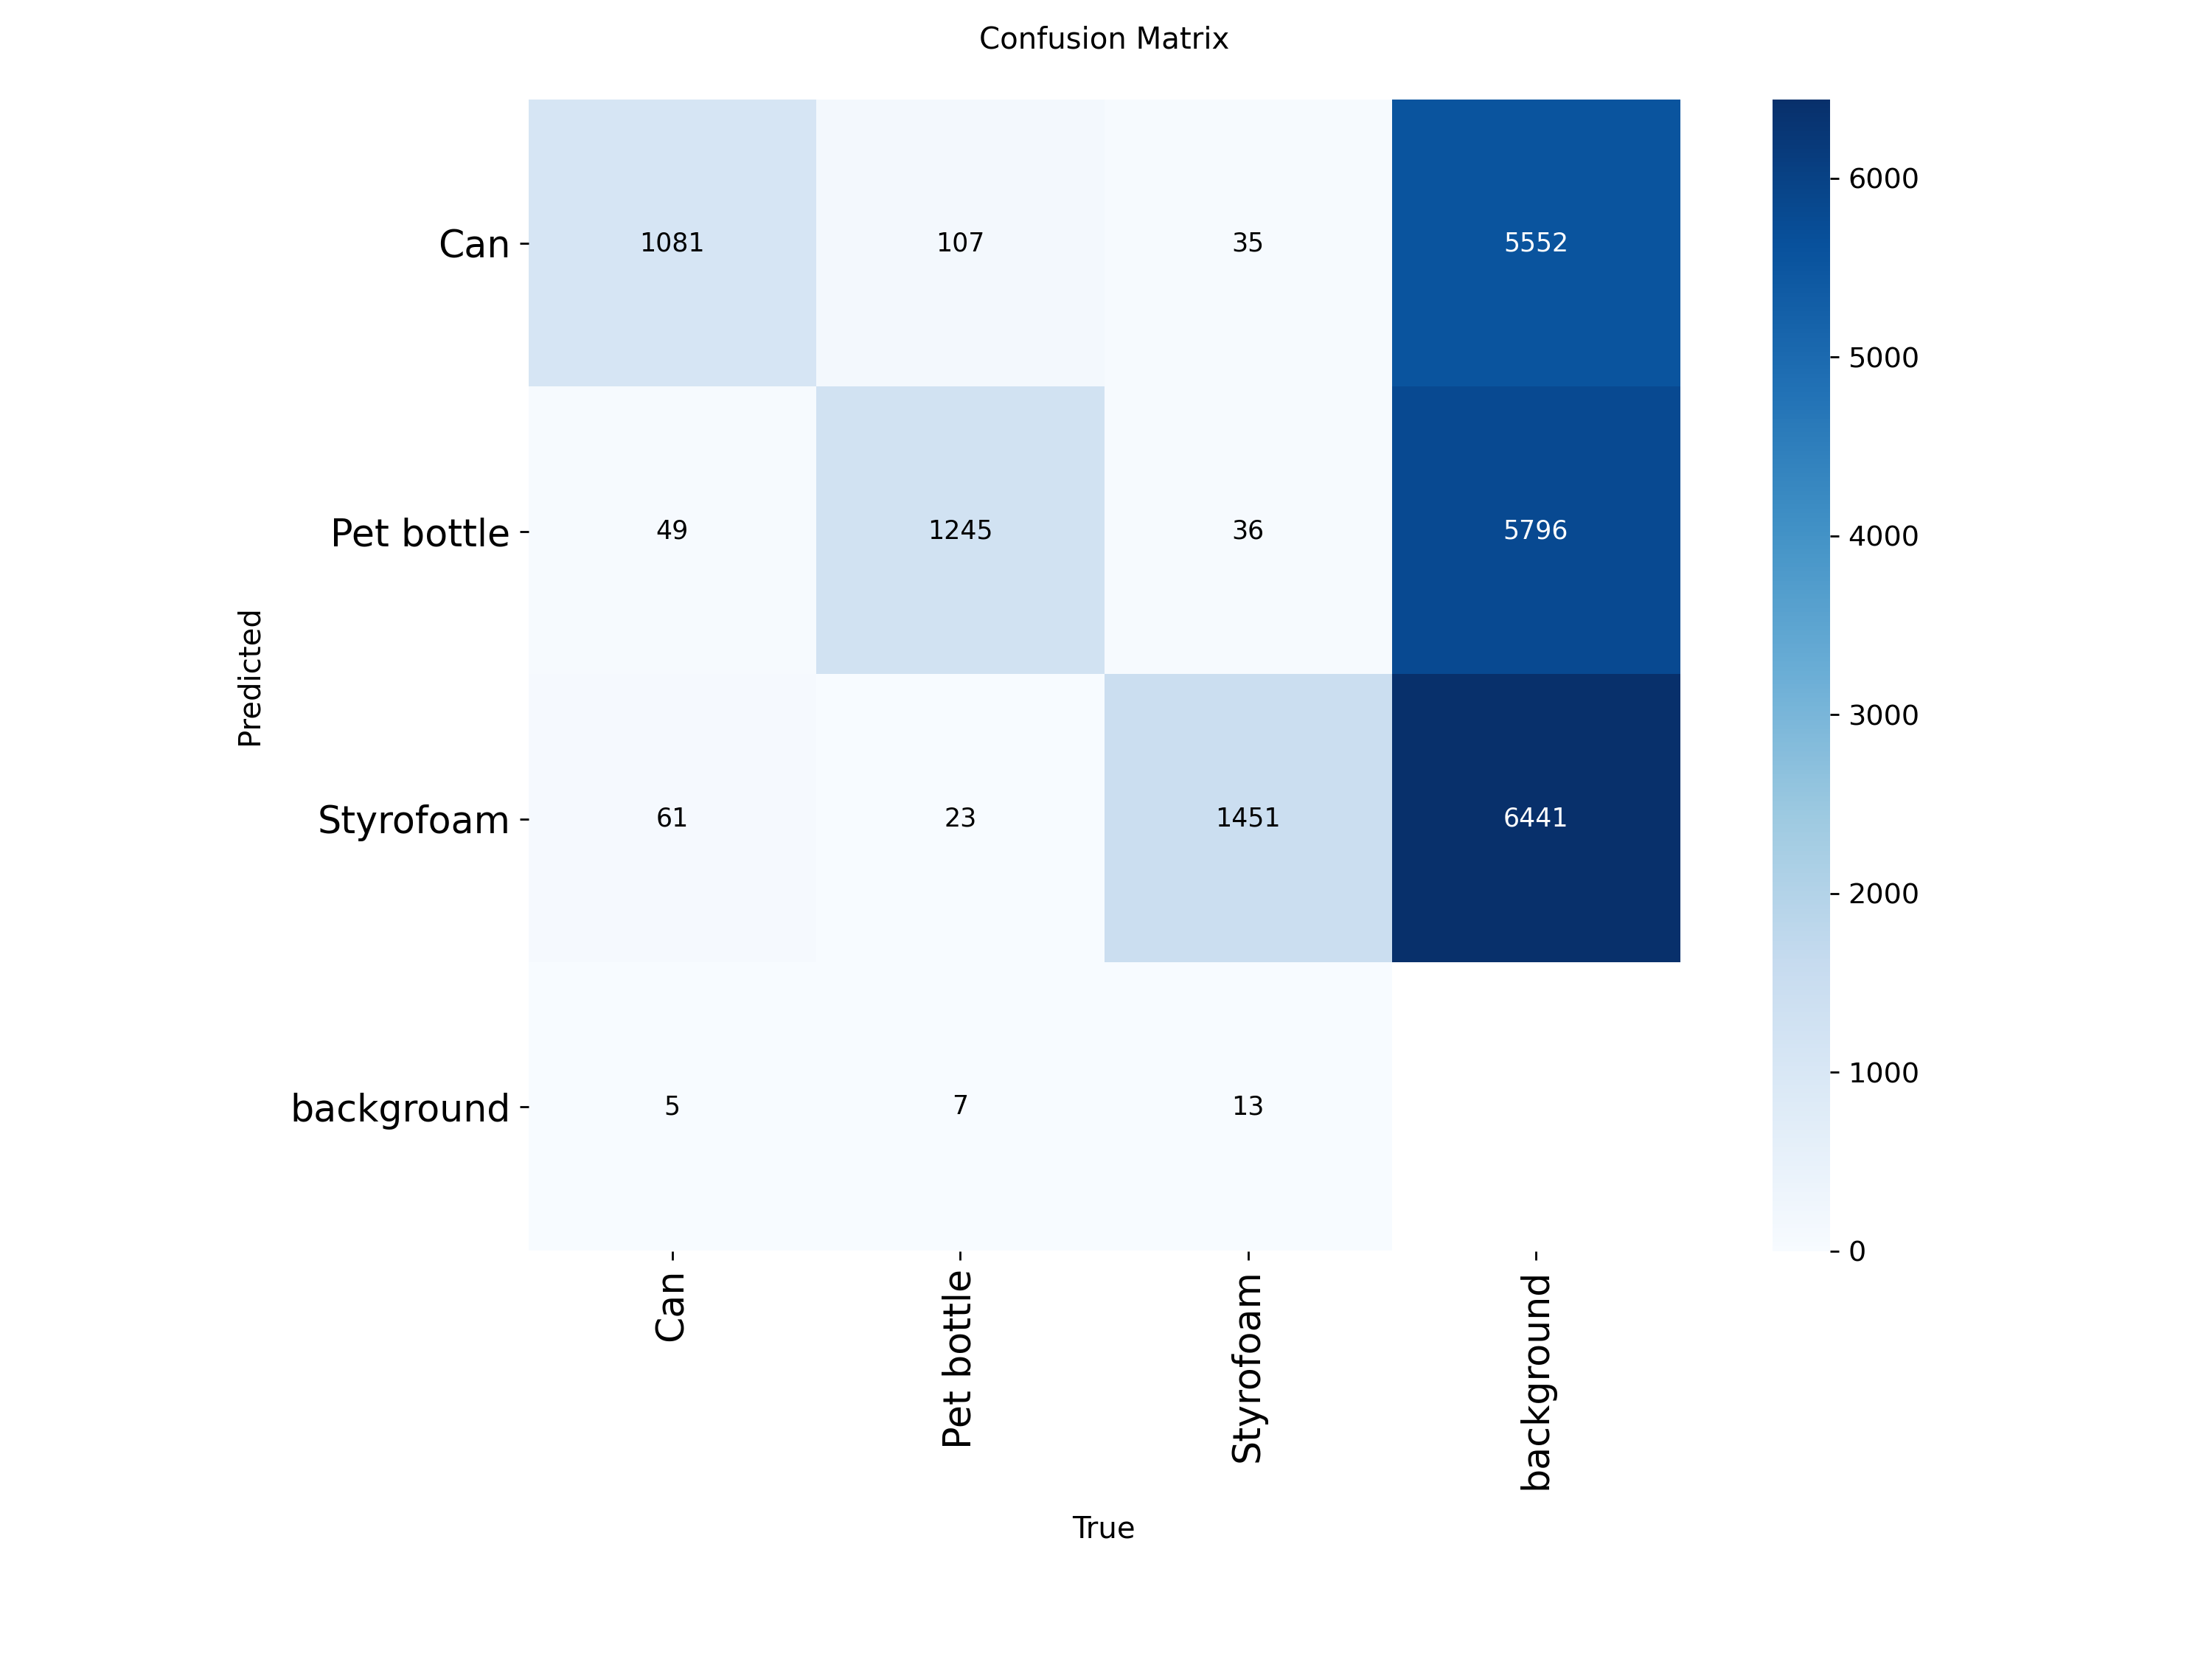

In [58]:
from IPython.display import Image, display
import glob

# 결과 이미지 경로
result_dir = Path("runs/detect/runs/exp01/hnm_training")

# 혼동행렬
confusion_path = result_dir / "confusion_matrix.png"
if confusion_path.exists():
    print("=== Confusion Matrix ===")
    display(Image(filename=str(confusion_path)))
else:
    print("Confusion matrix not found")

print()

=== PR Curve ===


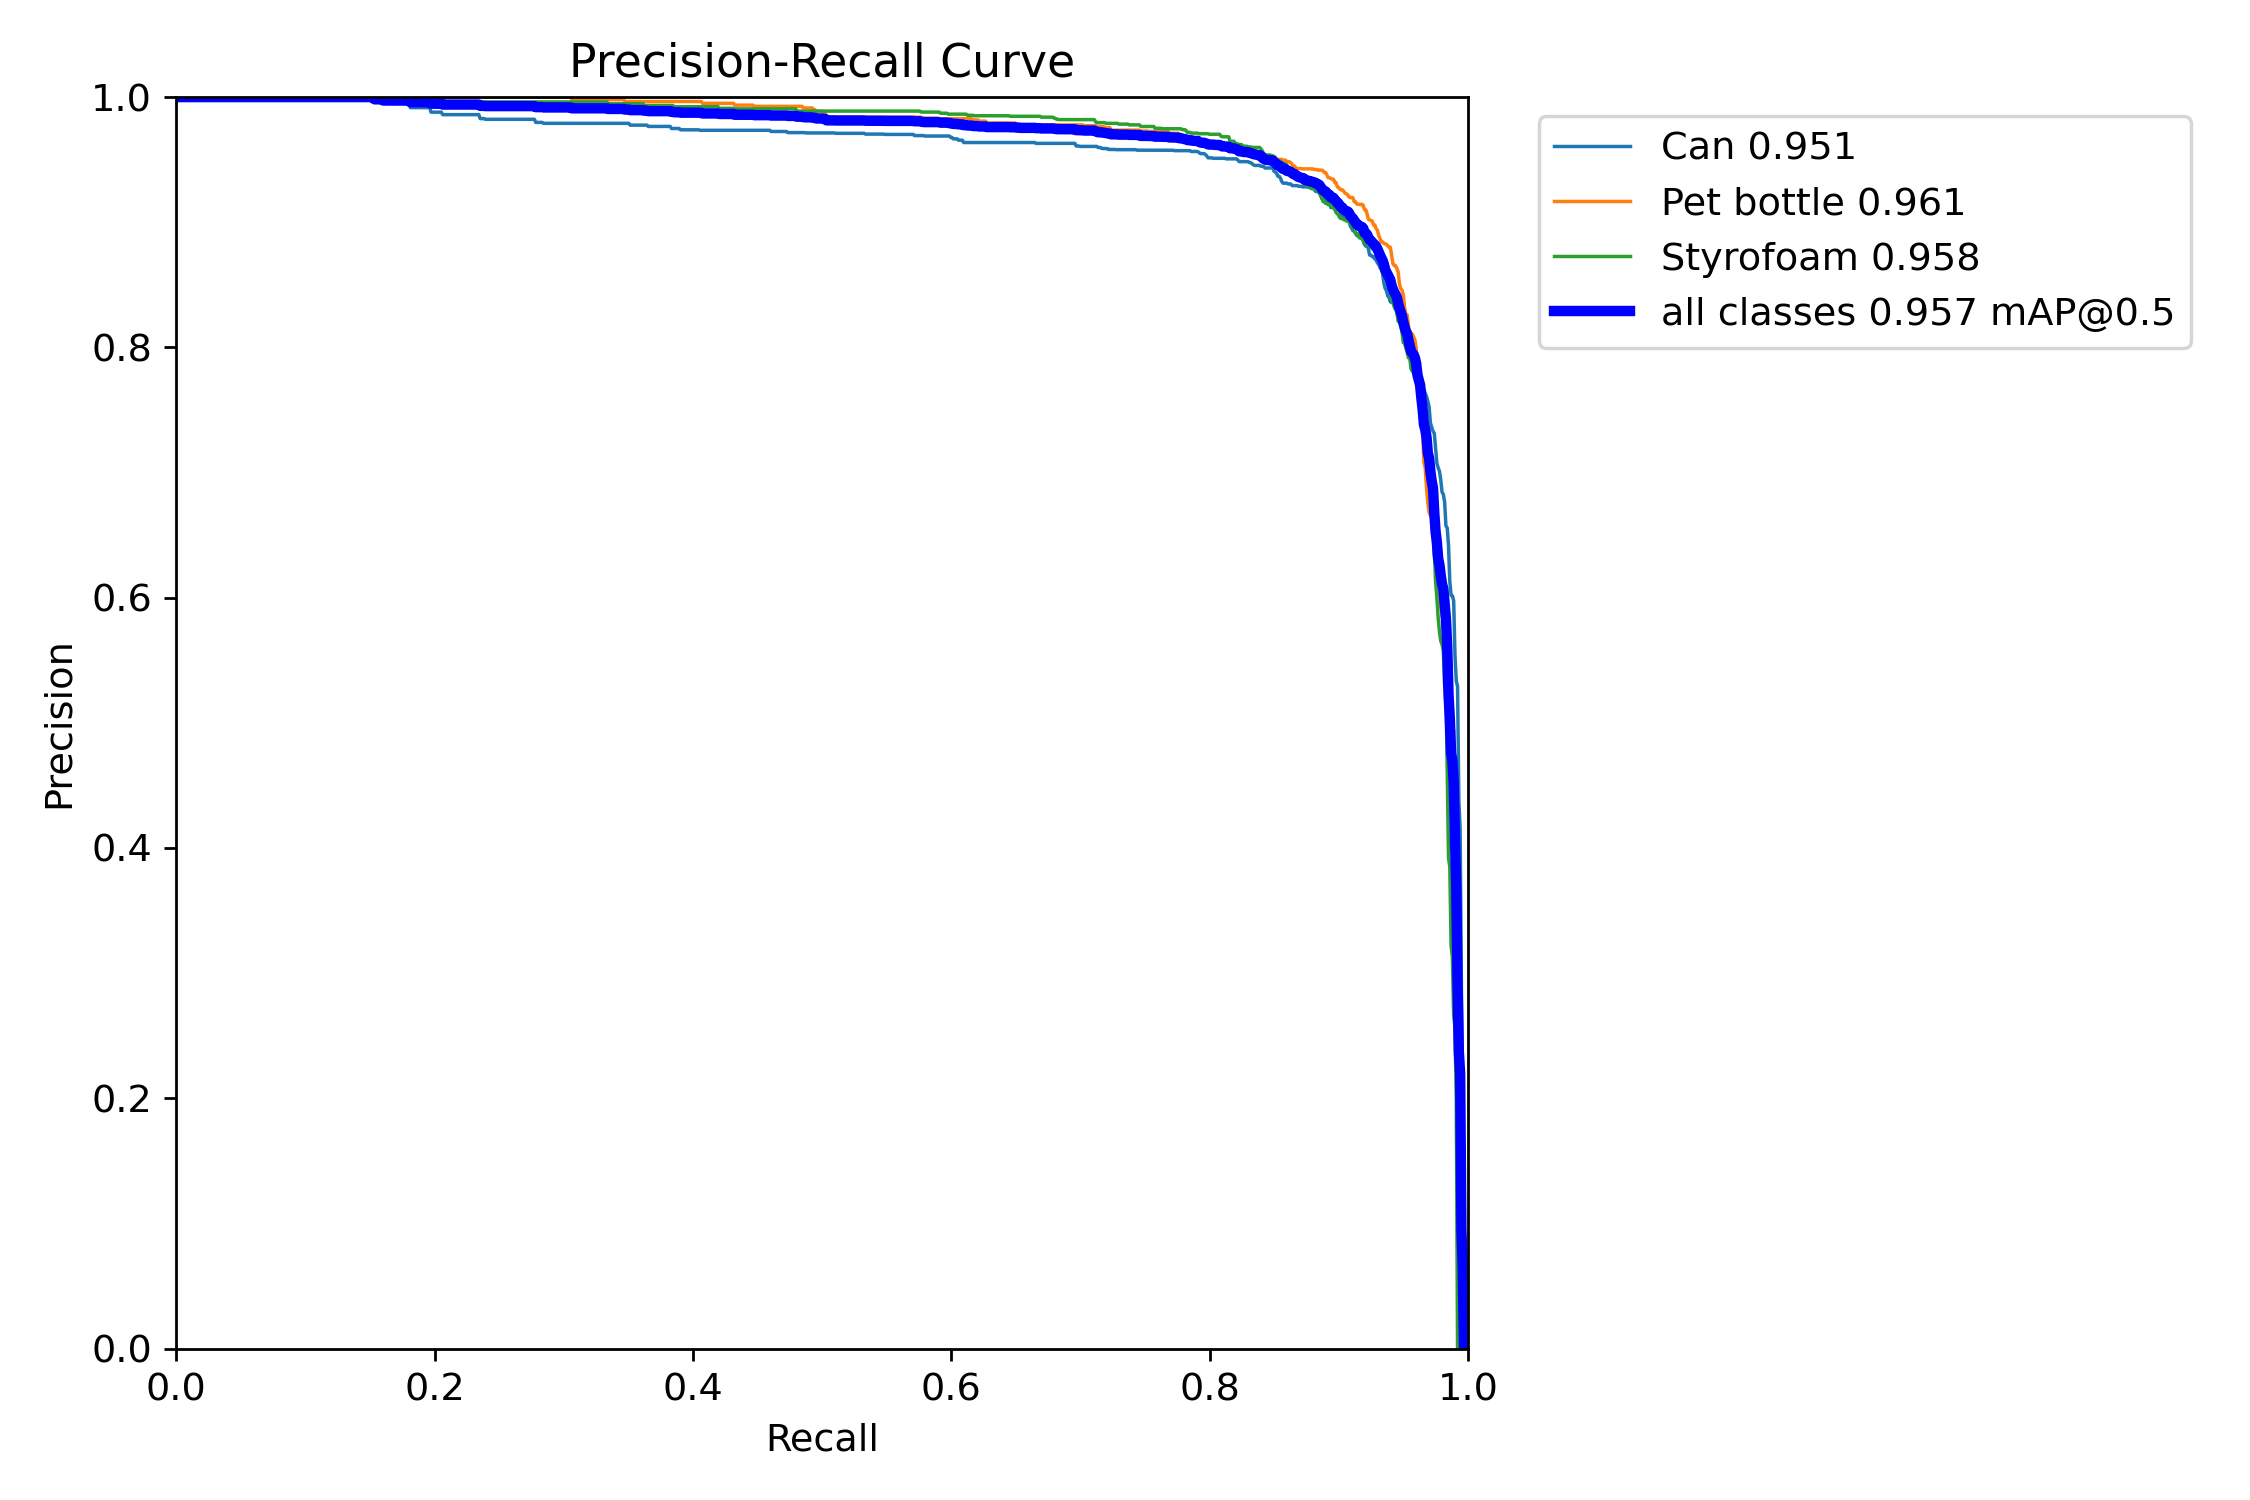

In [60]:
# PR Curve
pr_path = result_dir / "BoxPR_curve.png"
if pr_path.exists():
    print("=== PR Curve ===")
    display(Image(filename=str(pr_path)))
else:
    print("PR curve not found")

=== Training Results ===


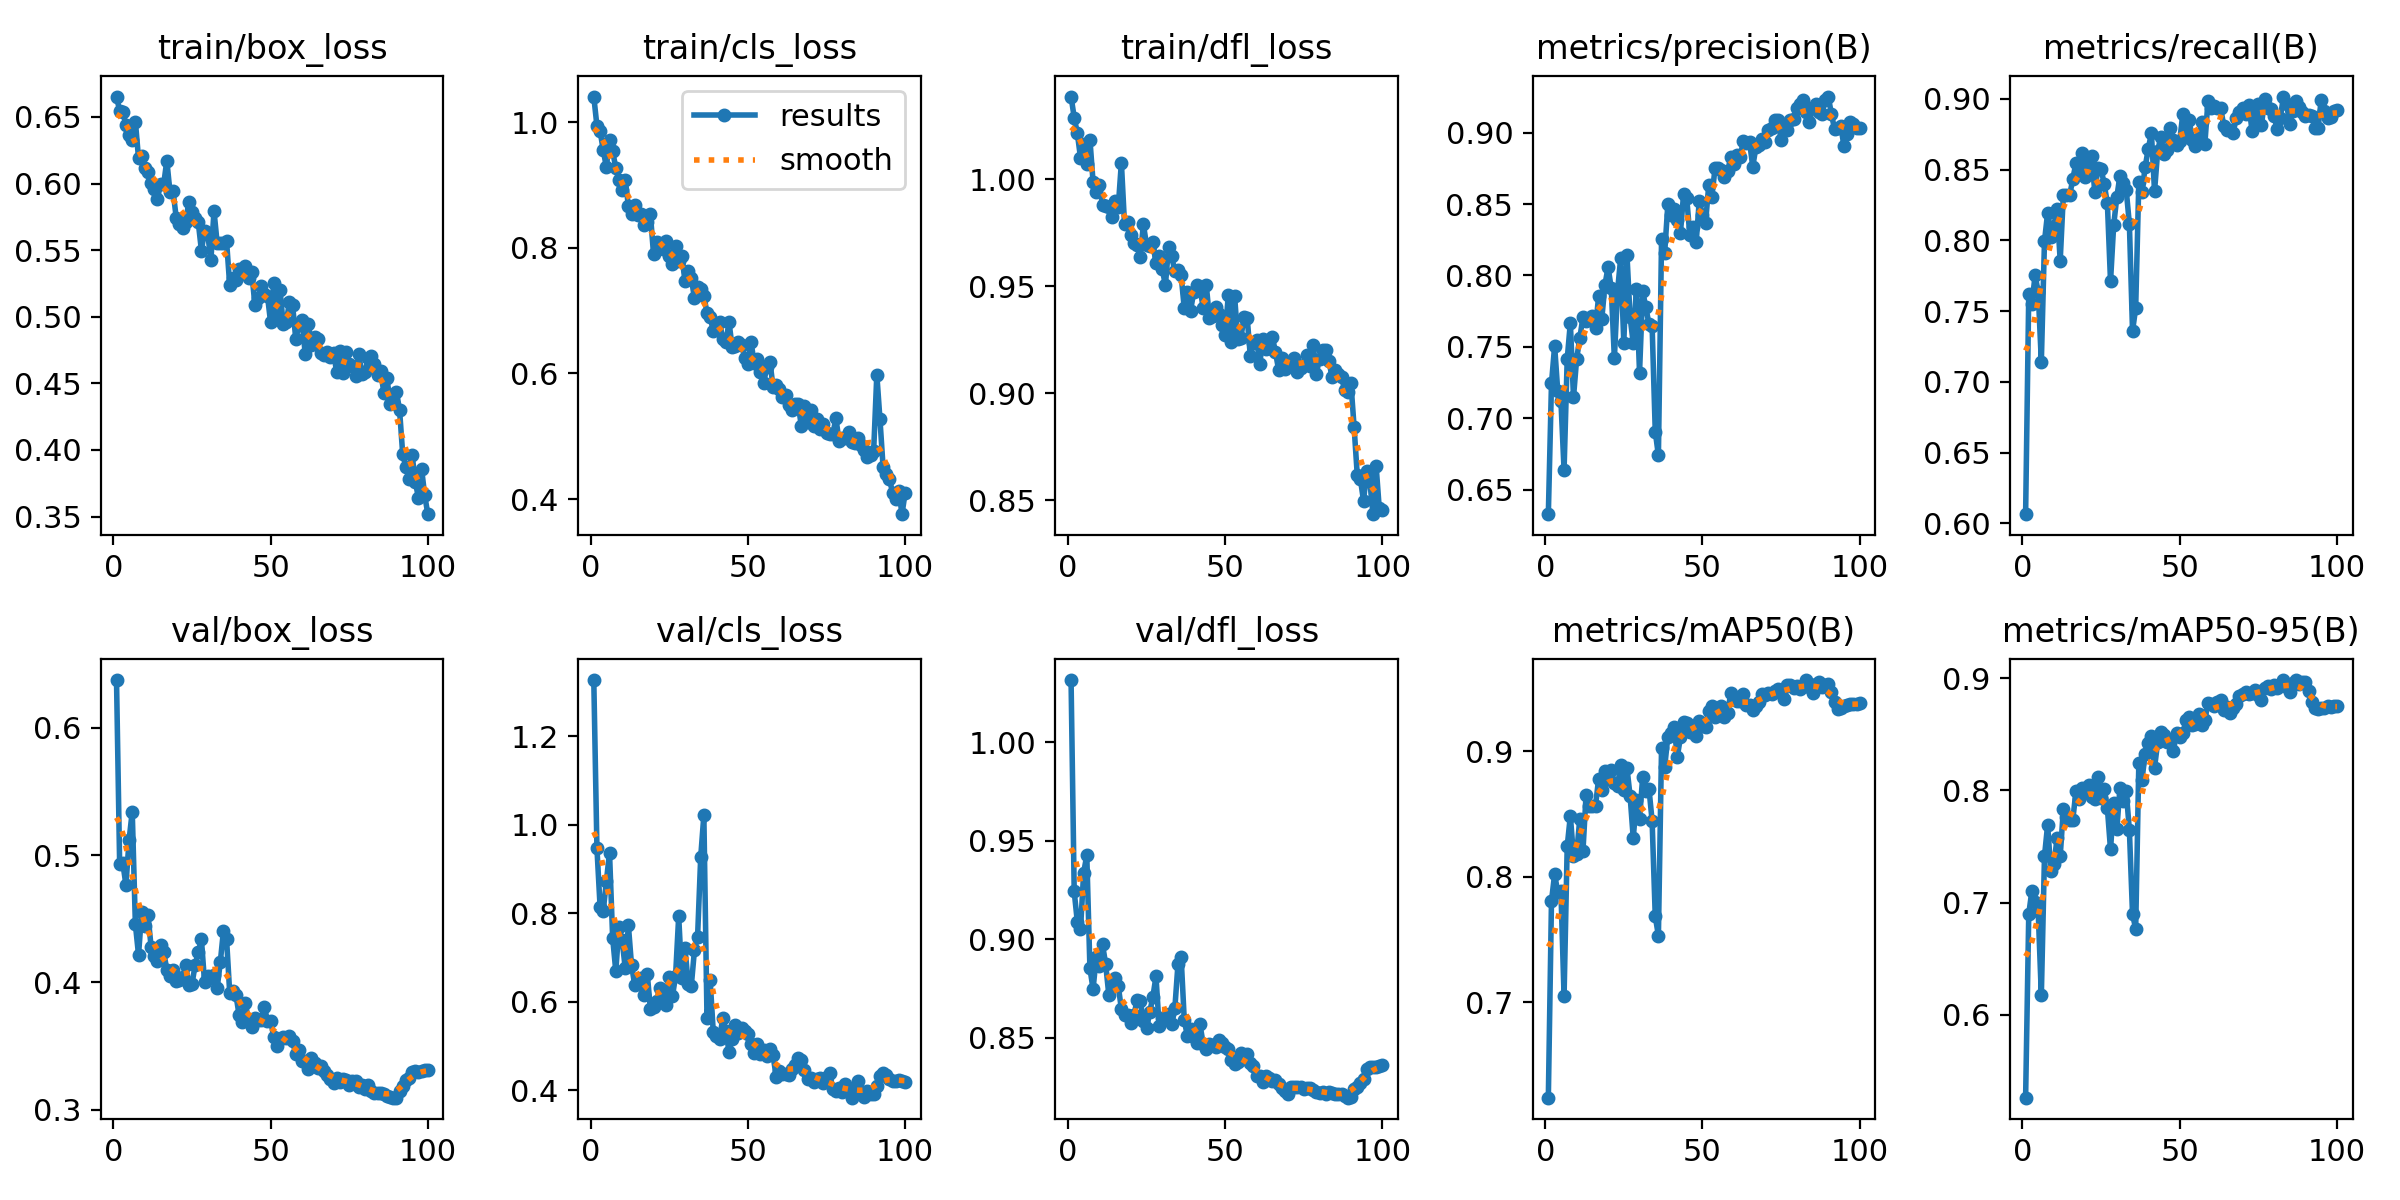

In [61]:
# 학습 곡선 (Results)
results_path = result_dir / "results.png"
if results_path.exists():
    print("=== Training Results ===")
    display(Image(filename=str(results_path)))
else:
    print("Results plot not found")

In [62]:
# 클래스별 성능
print("=== Per-Class Results ===")
if hasattr(val_results, 'names'):
    class_names = val_results.names
    print(f"Classes: {class_names}")

# 클래스별 mAP50
if hasattr(val_results, 'box'):
    print(f"\nOverall mAP50: {val_results.box.map50:.4f}")
    print(f"Overall mAP50-95: {val_results.box.map:.4f}")

=== Per-Class Results ===
Classes: {0: 'Can', 1: 'Pet bottle', 2: 'Styrofoam'}

Overall mAP50: 0.9570
Overall mAP50-95: 0.8983


In [38]:
import shutil

# 압축할 폴더의 경로 (다운로드하려는 폴더)
source_dir = '/content/runs'

# 저장될 압축 파일의 경로 및 이름 (확장자 포함)
output_filename = '/content/runs.zip'

# 압축 실행
shutil.make_archive(output_filename.replace('.zip', ''), 'zip', source_dir)
print("압축이 완료되었습니다!")

압축이 완료되었습니다!
